# Catalog covariance ratio: simulation / analytic

This notebook builds a publication-quality comparison plot for the catalog case:
- ratio of diagonal covariance entries, $\mathrm{Cov}_{\rm sim}/\mathrm{Cov}_{\rm analytic}$
- overlaid jackknife $1\sigma$ uncertainty band

It follows the same plotting style used in your Pk notebook (serif, inward ticks, clean palette).

Using analytic file: /Users/robert/Documents/Git/cpcl_gpu/plots/covariance_forecast_analytic.npz
Using simulation file: /Users/robert/Documents/Git/cpcl_gpu/plots/mock_masked_fixed.npz


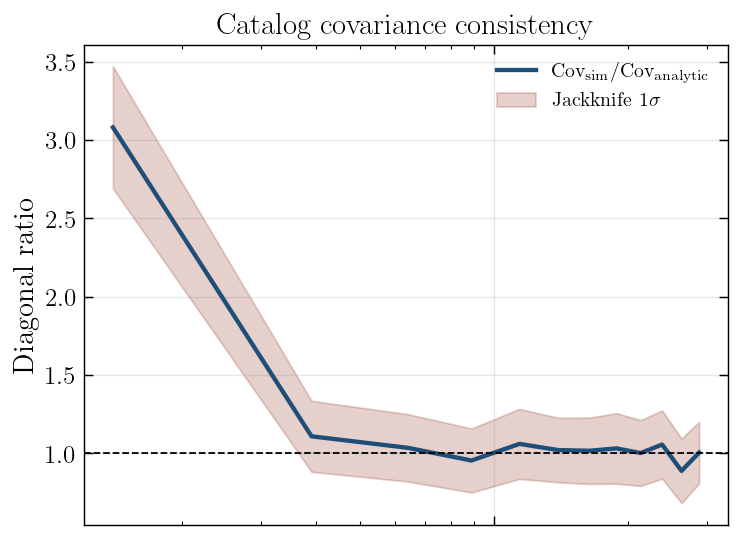

Saved: /Users/robert/Documents/Git/cpcl_gpu/plots/covariance_catalog_ratio_jackknife.pdf


In [12]:
from pathlib import Path
import shutil

import numpy as np
import matplotlib.pyplot as plt

# ---- plotting style (matching your standard notebook style) -----------------
_fs, _fs2 = 14, 17
if shutil.which("latex") is not None:
    plt.rc("text", usetex=True)
    plt.rcParams["font.serif"] = ["Computer Modern"]

plt.rc("font", family="serif")
plt.rcParams.update({
    "font.size": _fs,
    "axes.titlesize": _fs2,
    "axes.labelsize": _fs2 - 1,
    "xtick.labelsize": _fs,
    "ytick.labelsize": _fs,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": False,
    "legend.frameon": False,
    "figure.dpi": 130,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.top": True,
    "ytick.right": True,
})

C_BLUE = "#1f4e79"
C_ORANGE = "#8c2d19"
C_GREEN = "#2d6a4f"
C_GRAY = "#6c757d"


# ---- data loading helpers ---------------------------------------------------
def pick_existing(paths):
    for p in paths:
        if p.exists():
            return p
    raise FileNotFoundError("None of the candidate files exist:\n" + "\n".join(str(p) for p in paths))


def locate_in_candidates(filenames, directories):
    candidates = [d / fn for d in directories for fn in filenames]
    return pick_existing(candidates)


def get_first_available(data, keys):
    for k in keys:
        if k in data.files:
            return data[k]
    return None


def jackknife_cov_error(pcl_dm, n_blocks=100):
    pcl_dm = np.asarray(pcl_dm)
    n_real = pcl_dm.shape[0]

    # Keep blocks valid even for small ensembles.
    n_blocks = min(n_blocks, max(2, n_real // 4))
    block_size = n_real // n_blocks
    if block_size < 1:
        raise ValueError("Not enough realizations for jackknife block estimate")

    cov_full = np.cov(pcl_dm.T)
    cov_jk = np.zeros((n_blocks, cov_full.shape[0], cov_full.shape[1]))

    for k in range(n_blocks):
        mask = np.ones(n_real, dtype=bool)
        i0 = k * block_size
        i1 = (k + 1) * block_size if k < n_blocks - 1 else n_real
        mask[i0:i1] = False
        cov_jk[k] = np.cov(pcl_dm[mask].T)

    cov_jk_mean = cov_jk.mean(axis=0)
    cov_err = np.sqrt((n_blocks - 1) / n_blocks * np.sum((cov_jk - cov_jk_mean) ** 2, axis=0))
    return cov_err


# ---- pick files (catalog preferred) -----------------------------------------
cwd = Path.cwd().resolve()
dirs_to_try = [cwd, cwd / "plots", cwd.parent, cwd.parent / "plots"]

analytic_path = locate_in_candidates(
    ["covariance_forecast_analytic.npz"],
    dirs_to_try,
)
sim_path = locate_in_candidates(
    ["mock_masked_fixed.npz"],
    dirs_to_try,
)
plots_dir = analytic_path.parent

print(f"Using analytic file: {analytic_path}")
print(f"Using simulation file: {sim_path}")

ana = np.load(analytic_path)
sim = np.load(sim_path)

cov_analytic = get_first_available(ana, ["cov_theory", "cov_analytic", "cov_gpu_th", "cov"])
if cov_analytic is None:
    raise KeyError(f"Could not find analytic covariance key in {analytic_path}: {ana.files}")

ell_eff = get_first_available(sim, ["pcl_ell_eff", "ell_eff"])
if ell_eff is None:
    ell_eff = get_first_available(ana, ["ell_eff", "pcl_ell_eff"])
if ell_eff is None:
    raise KeyError("No ell_eff/pcl_ell_eff found in either simulation or analytic file")

# Simulation covariance from pseudo-Cl realizations.
if "pcl_dm" in sim.files:
    pcl_dm = sim["pcl_dm"]
    cov_sim = np.cov(pcl_dm.T)
else:
    cov_sim = get_first_available(sim, ["cov_sim", "cov", "covariance"])
    if cov_sim is None:
        raise KeyError(f"Could not build simulation covariance from {sim_path}: {sim.files}")
    pcl_dm = None

# Jackknife covariance uncertainty matrix: use precomputed one if available,
# otherwise compute it from the simulation realizations.
cov_err = get_first_available(ana, ["cov_err", "covariance_err"])
if cov_err is None:
    if pcl_dm is None:
        raise KeyError("No cov_err available and no pcl_dm realizations to estimate jackknife errors")
    cov_err = jackknife_cov_error(pcl_dm, n_blocks=100)

# Keep only matching diagonal length.
n = min(cov_sim.shape[0], cov_analytic.shape[0], len(ell_eff))
ell_eff = np.asarray(ell_eff)[:n]
diag_sim = np.diag(cov_sim)[:n]
diag_ana = np.diag(cov_analytic)[:n]
diag_cov_err = np.diag(cov_err)[:n]

# Ratio and propagated jackknife uncertainty.
ratio = diag_sim / diag_ana
frac_jk = np.divide(diag_cov_err, diag_sim, out=np.zeros_like(diag_cov_err), where=diag_sim > 0)
sigma_ratio = ratio * frac_jk

# ---- plot -------------------------------------------------------------------
fig = plt.figure()
gs = fig.add_gridspec()
ax0 = fig.add_subplot(gs[0])

ax0.semilogx(ell_eff, ratio, color=C_BLUE, lw=2.4, label=r"$\mathrm{Cov}_{\rm sim}/\mathrm{Cov}_{\rm analytic}$")
ax0.fill_between(
    ell_eff,
    ratio - sigma_ratio**.5,
    ratio + sigma_ratio**.5,
    color=C_ORANGE,
    alpha=0.22,
    label=r"Jackknife $1\sigma$",
)
ax0.axhline(1.0, color="black", lw=1.0, ls="--")
ax0.set_ylabel(r"Diagonal ratio")
ax0.set_title(r"Catalog covariance consistency")
ax0.legend(loc="best", fontsize=11)
ax0.grid(which="major", alpha=0.16, color=C_GRAY, linestyle="-")
plt.setp(ax0.get_xticklabels(), visible=False)

out_pdf = plots_dir / "covariance_catalog_ratio_jackknife.pdf"
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()

print(f"Saved: {out_pdf}")